# Model Evaluation on Teacher Datasets

This notebook loads pre-trained models and evaluates them on the teacher datasets:
1. Load pre-trained models from '../../trained_models/tensorflow/'
2. Load teacher datasets from '../../datasets/'
3. Preprocess the text data for each model
4. Make predictions with each model
5. Compare predictions with actual labels
6. Calculate and visualize accuracy metrics


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import re
import pickle
import glob
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


## Define Preprocessing Functions

In [49]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

def extract_features(texts):
    print("Extracting features...")
    features = []
    stop_words = set(stopwords.words("english"))
    
    for text in texts:
        if not isinstance(text, str) or not text.strip():
            features.append([0] * 8)
            continue
            
        words = word_tokenize(text)
        
        if not words:
            features.append([0] * 8)
            continue
            
        num_words = len(words)
        num_chars = len(text)
        avg_word_length = np.mean([len(w) for w in words]) if words else 0
        num_stopwords = sum(1 for word in words if word.lower() in stop_words)
        stopword_ratio = num_stopwords / num_words if num_words else 0
        
        num_punctuation = sum(1 for char in text if char in string.punctuation)
        punctuation_ratio = num_punctuation / num_chars if num_chars else 0
        
        lexical_diversity = len(set(words)) / num_words if num_words else 0
        
        feature_vector = [
            num_words,
            num_chars,
            avg_word_length,
            num_stopwords,
            stopword_ratio,
            num_punctuation,
            punctuation_ratio,
            lexical_diversity
        ]
        
        features.append(feature_vector)
        
    return np.array(features)


## Load Datasets

In [50]:

teacher_inputs_path = "../datasets/clean/teacher_inputs.csv"
teacher_inputs = pd.read_csv(teacher_inputs_path, sep="\t")
print(f"Teacher inputs shape: {teacher_inputs.shape}")
print(teacher_inputs.head())

teacher_outputs_path = "../datasets/clean/teacher_outputs.csv"
teacher_outputs = pd.read_csv(teacher_outputs_path, sep="\t")
print(f"\nTeacher outputs shape: {teacher_outputs.shape}")
print(teacher_outputs.head())

teacher_data = pd.merge(teacher_inputs, teacher_outputs, on="ID")
print(f"\nMerged data shape: {teacher_data.shape}")
print(teacher_data.head())

teacher_data['numeric_label'] = teacher_data['Label'].apply(lambda x: 0 if x == 'Human' else 1)

print(f"\nLabel distribution: {teacher_data['Label'].value_counts().to_dict()}")


Teacher inputs shape: (80, 2)
     ID                                               Text
0  D1-1  The cell cycle, or cell-division cycle, is the...
1  D1-2  The cell cycle is the process by which a cell ...
2  D1-3  Photons, in many atomic models in physics, are...
3  D1-4  A photon is a fundamental particle of light an...
4  D1-5  According to the theory of plate tectonics, Ea...

Teacher outputs shape: (80, 2)
     ID  Label
0  D1-1  Human
1  D1-2     AI
2  D1-3  Human
3  D1-4     AI
4  D1-5  Human

Merged data shape: (80, 3)
     ID                                               Text  Label
0  D1-1  The cell cycle, or cell-division cycle, is the...  Human
1  D1-2  The cell cycle is the process by which a cell ...     AI
2  D1-3  Photons, in many atomic models in physics, are...  Human
3  D1-4  A photon is a fundamental particle of light an...     AI
4  D1-5  According to the theory of plate tectonics, Ea...  Human

Label distribution: {'Human': 41, 'AI': 39}


## Load Pre-trained Models

In [51]:

model_dir = "../trained_models/tensorflow/"

if not os.path.exists(model_dir):
    print(f"Model directory {model_dir} not found. Creating it.")
    os.makedirs(model_dir, exist_ok=True)
    print("No models found. Please train models first.")
else:
    print(f"Looking for models in {model_dir}")

model_files = glob.glob(os.path.join(model_dir, "*.h5"))
print(f"Found {len(model_files)} model files: {[os.path.basename(f) for f in model_files]}")

preprocessing_files = glob.glob(os.path.join(model_dir, "*.pkl"))
print(f"Found {len(preprocessing_files)} preprocessing files: {[os.path.basename(f) for f in preprocessing_files]}")

models = {}
preprocessors = {}

for model_file in model_files:
    model_name = os.path.basename(model_file).replace("_model.h5", "")
    
    try:
        print(f"Loading model: {model_name}")
        models[model_name] = keras.models.load_model(model_file)
        
        preprocessor_file = None
        for prep_file in preprocessing_files:
            if model_name in prep_file:
                preprocessor_file = prep_file
                break
        
        if preprocessor_file:
            print(f"Loading preprocessor: {os.path.basename(preprocessor_file)}")
            try:
                with open(preprocessor_file, 'rb') as f:
                    preprocessor = pickle.load(f)
                
                if "dnn" in model_name:
                    if isinstance(preprocessor, dict):
                        if 'extract_features' not in preprocessor or not callable(preprocessor['extract_features']):
                            preprocessor['extract_features'] = extract_features
                        if 'clean_text' not in preprocessor or not callable(preprocessor['clean_text']):
                            preprocessor['clean_text'] = clean_text
                    else:
                        preprocessor = {
                            'extract_features': extract_features,
                            'clean_text': clean_text
                        }
                
                elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
                    if isinstance(preprocessor, dict):
                        if 'clean_text' not in preprocessor or not callable(preprocessor['clean_text']):
                            preprocessor['clean_text'] = clean_text
                        
                        if 'tokenizer' not in preprocessor and 'max_seq_length' not in preprocessor:
                            if hasattr(preprocessor, 'word_index'):
                                tokenizer = preprocessor
                                preprocessor = {
                                    'tokenizer': tokenizer,
                                    'max_seq_length': 128,
                                    'clean_text': clean_text
                                }
                    else:
                        if hasattr(preprocessor, 'word_index'):
                            tokenizer = preprocessor
                            preprocessor = {
                                'tokenizer': tokenizer,
                                'max_seq_length': 128,
                                'clean_text': clean_text
                            }
                        else:
                            print(f"Creating new tokenizer for {model_name}")
                            tokenizer = Tokenizer(num_words=2500, oov_token="<OOV>")
                            preprocessor = {
                                'tokenizer': tokenizer,
                                'max_seq_length': 128,
                                'clean_text': clean_text
                            }
                
                elif "ensemble" in model_name:
                    if isinstance(preprocessor, dict):
                        if 'clean_text' not in preprocessor or not callable(preprocessor['clean_text']):
                            preprocessor['clean_text'] = clean_text
                        if 'extract_features' not in preprocessor or not callable(preprocessor['extract_features']):
                            preprocessor['extract_features'] = extract_features
                
                preprocessors[model_name] = preprocessor
                print(f"Successfully loaded and fixed preprocessor for {model_name}")
                
            except Exception as e:
                print(f"Error loading preprocessor for {model_name}: {str(e)}")
                if "dnn" in model_name:
                    preprocessors[model_name] = {
                        'extract_features': extract_features,
                        'clean_text': clean_text
                    }
                elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
                    print(f"Creating new tokenizer for {model_name}")
                    tokenizer = Tokenizer(num_words=2500, oov_token="<OOV>")
                    preprocessors[model_name] = {
                        'tokenizer': tokenizer,
                        'max_seq_length': 128,
                        'clean_text': clean_text
                    }
        else:
            print(f"No preprocessor found for {model_name}, creating default preprocessor")
            if "dnn" in model_name:
                preprocessors[model_name] = {
                    'extract_features': extract_features,
                    'clean_text': clean_text
                }
            elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
                print(f"Creating new tokenizer for {model_name}")
                tokenizer = Tokenizer(num_words=2500, oov_token="<OOV>")
                preprocessors[model_name] = {
                    'tokenizer': tokenizer,
                    'max_seq_length': 128,
                    'clean_text': clean_text
                }
    except Exception as e:
        print(f"Error loading {model_name}: {str(e)}")

print(f"\nLoaded {len(models)} models: {list(models.keys())}")

for model_name, preprocessor in preprocessors.items():
    if any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
        if 'tokenizer' in preprocessor and not hasattr(preprocessor['tokenizer'], 'word_index'):
            print(f"Fitting tokenizer for {model_name} on teacher data")
            preprocessor['tokenizer'].fit_on_texts(teacher_data['Text'].values)


Looking for models in ../trained_models/tensorflow/
Found 5 model files: ['cnn_model.h5', 'gru_model.h5', 'ensemble_model.h5', 'dnn_model.h5', 'lstm_model.h5']
Found 5 preprocessing files: ['gru_tokenizer.pkl', 'dnn_tokenizer.pkl', 'lstm_tokenizer.pkl', 'cnn_tokenizer.pkl', 'ensemble_tokenizer.pkl']
Loading model: cnn
Loading preprocessor: cnn_tokenizer.pkl
Successfully loaded and fixed preprocessor for cnn
Loading model: gru


Loading preprocessor: gru_tokenizer.pkl
Successfully loaded and fixed preprocessor for gru
Loading model: ensemble


Loading preprocessor: ensemble_tokenizer.pkl
Successfully loaded and fixed preprocessor for ensemble
Loading model: dnn
Loading preprocessor: dnn_tokenizer.pkl
Successfully loaded and fixed preprocessor for dnn
Loading model: lstm
Loading preprocessor: lstm_tokenizer.pkl
Successfully loaded and fixed preprocessor for lstm

Loaded 5 models: ['cnn', 'gru', 'ensemble', 'dnn', 'lstm']


## Preprocess Data

In [52]:
def preprocess_for_model(texts, model_name, preprocessor):
    
    if "dnn" in model_name:
        if 'extract_features' in preprocessor and 'clean_text' in preprocessor:
            cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
            features = preprocessor['extract_features'](cleaned_texts)
            return features
        else:
            print(f"Missing required preprocessing functions for {model_name}")
            return None
    
    elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer", "cnn"]):
        if 'tokenizer' in preprocessor and 'max_seq_length' in preprocessor and 'clean_text' in preprocessor:
            cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
            sequences = preprocessor['tokenizer'].texts_to_sequences(cleaned_texts)
            padded = pad_sequences(sequences, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
            return padded
        else:
            print(f"Missing required preprocessing components for {model_name}")
            return None
    
    elif "ensemble" in model_name:
        if isinstance(preprocessor, dict) and 'model_names' in preprocessor:
            inputs = []
            for i, input_type in enumerate(preprocessor['input_types']):
                if input_type == 'features':
                    cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
                    features = preprocessor['extract_features'](cleaned_texts)
                    inputs.append(features)
                else:
                    cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
                    sequences = preprocessor['tokenizer'].texts_to_sequences(cleaned_texts)
                    padded = pad_sequences(sequences, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
                    inputs.append(padded)
            return inputs
        else:
            print(f"Invalid preprocessor format for {model_name}")
            return None
    
    else:
        print(f"Unknown model type: {model_name}")
        return None

processed_data = {}
for model_name, model in models.items():
    if model_name in preprocessors:
        print(f"Preprocessing data for {model_name}...")
        processed_data[model_name] = preprocess_for_model(teacher_data['Text'].values, model_name, preprocessors[model_name])
        
        if processed_data[model_name] is not None:
            if isinstance(processed_data[model_name], list):
                print(f"  Processed data shapes: {[x.shape for x in processed_data[model_name]]}")
            else:
                print(f"  Processed data shape: {processed_data[model_name].shape}")
    else:
        print(f"No preprocessor available for {model_name}, skipping...")


Preprocessing data for cnn...
  Processed data shape: (80, 128)
Preprocessing data for gru...
  Processed data shape: (80, 128)
Preprocessing data for ensemble...
Extracting features...
  Processed data shapes: [(80, 8), (80, 128), (80, 128)]
Preprocessing data for dnn...
Extracting features...
  Processed data shape: (80, 8)
Preprocessing data for lstm...
  Processed data shape: (80, 128)


## Make Predictions

In [53]:
predictions = {}
probabilities = {}

for model_name, model in models.items():
    if model_name in processed_data and processed_data[model_name] is not None:
        print(f"Making predictions with {model_name}...")
        
        try:
            if isinstance(processed_data[model_name], list):
                probs = model.predict(processed_data[model_name])
            else:
                probs = model.predict(processed_data[model_name])
            
            preds = (probs > 0.5).astype(int)
            
            predictions[model_name] = preds.flatten()
            probabilities[model_name] = probs.flatten()
            
            print(f"  Made {len(predictions[model_name])} predictions")
        except Exception as e:
            print(f"  Error making predictions with {model_name}: {str(e)}")

results_df = teacher_data[['ID', 'Text', 'Label', 'numeric_label']].copy()

for model_name in predictions.keys():
    results_df[f'{model_name}_prob'] = probabilities[model_name]
    results_df[f'{model_name}_pred'] = predictions[model_name]
    results_df[f'{model_name}_correct'] = results_df['numeric_label'] == results_df[f'{model_name}_pred']

print("\nSample of prediction results:")
display_cols = ['ID', 'Label'] + [col for col in results_df.columns if '_prob' in col or '_pred' in col or '_correct' in col]
print(results_df[display_cols].head())


Making predictions with cnn...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
  Made 80 predictions
Making predictions with gru...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step
  Made 80 predictions
Making predictions with ensemble...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step
  Made 80 predictions
Making predictions with dnn...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
  Made 80 predictions
Making predictions with lstm...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step
  Made 80 predictions

Sample of prediction results:
     ID  Label  cnn_prob  cnn_pred  cnn_correct  gru_prob  gru_pred  \
0  D1-1  Human  0.003228         0         True  0.014226         0   
1  D1-2     AI  0.003432         0        False  0.228027         0   
2  D1-3  Human  0.000153         0         True  0.003777         0   
3  D1-4     AI  0.690631         1         True  0.004087         0   
4  D1-5  Human  0.001464         0         True  0.004180         0   

   gru_correct  ensemble_prob  ensemble_pred  ensemble_correct  dnn_prob  \
0 

## Evaluate Models

cnn accuracy: 0.8000
gru accuracy: 0.7375
ensemble accuracy: 0.7500
dnn accuracy: 0.7500
lstm accuracy: 0.7750

Detailed Classification Reports:

CNN Classification Report:
              precision    recall  f1-score   support

       Human       0.73      0.98      0.83        41
          AI       0.96      0.62      0.75        39

    accuracy                           0.80        80
   macro avg       0.84      0.80      0.79        80
weighted avg       0.84      0.80      0.79        80



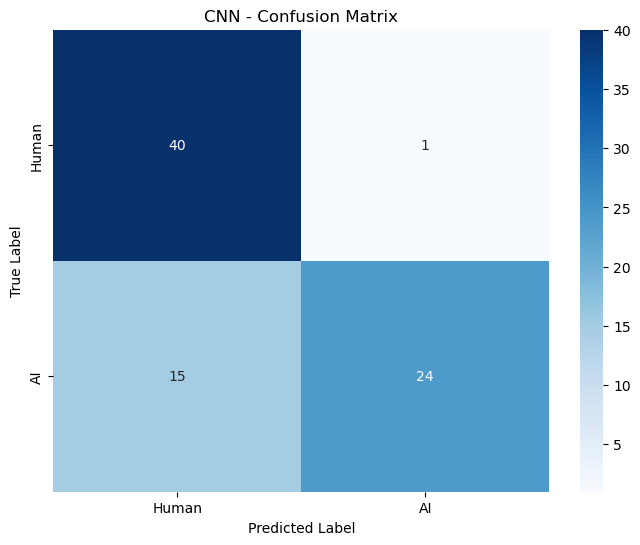


GRU Classification Report:
              precision    recall  f1-score   support

       Human       0.66      1.00      0.80        41
          AI       1.00      0.46      0.63        39

    accuracy                           0.74        80
   macro avg       0.83      0.73      0.71        80
weighted avg       0.83      0.74      0.72        80



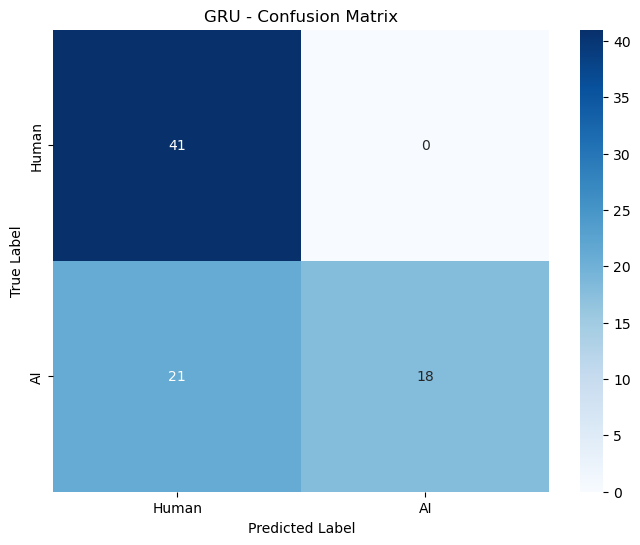


ENSEMBLE Classification Report:
              precision    recall  f1-score   support

       Human       0.68      0.98      0.80        41
          AI       0.95      0.51      0.67        39

    accuracy                           0.75        80
   macro avg       0.82      0.74      0.73        80
weighted avg       0.81      0.75      0.74        80



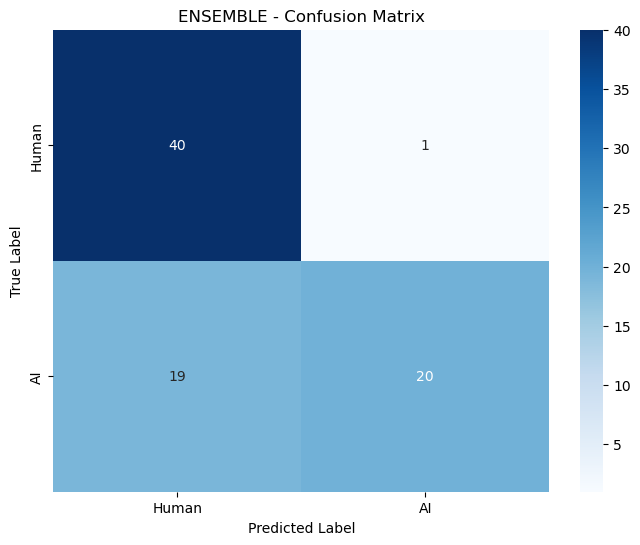


DNN Classification Report:
              precision    recall  f1-score   support

       Human       0.80      0.68      0.74        41
          AI       0.71      0.82      0.76        39

    accuracy                           0.75        80
   macro avg       0.76      0.75      0.75        80
weighted avg       0.76      0.75      0.75        80



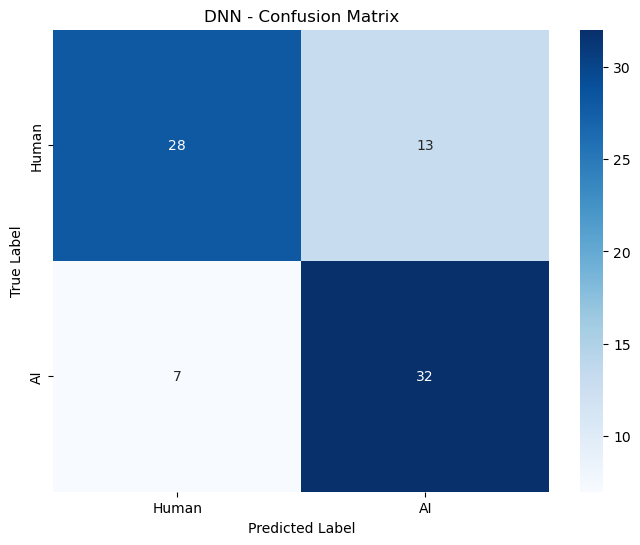


LSTM Classification Report:
              precision    recall  f1-score   support

       Human       0.70      0.98      0.82        41
          AI       0.96      0.56      0.71        39

    accuracy                           0.78        80
   macro avg       0.83      0.77      0.76        80
weighted avg       0.83      0.78      0.76        80



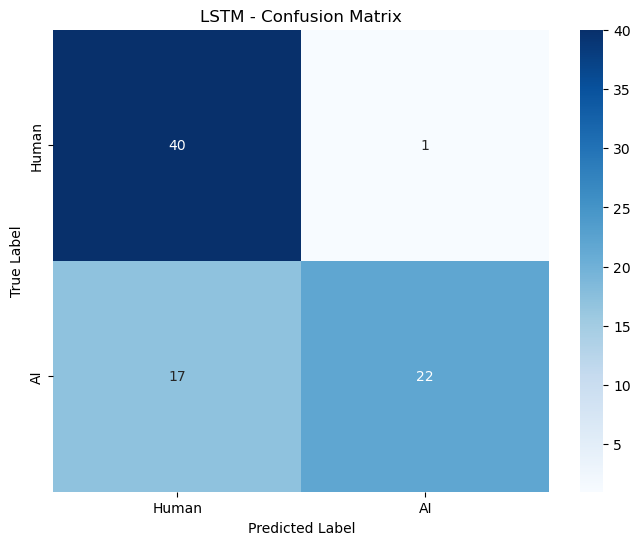

In [54]:
accuracies = {}
for model_name in predictions.keys():
    accuracies[model_name] = accuracy_score(results_df['numeric_label'], results_df[f'{model_name}_pred'])
    print(f"{model_name} accuracy: {accuracies[model_name]:.4f}")

print("\nDetailed Classification Reports:")
for model_name in predictions.keys():
    print(f"\n{model_name.upper()} Classification Report:")
    print(classification_report(
        results_df['numeric_label'], 
        results_df[f'{model_name}_pred'],
        target_names=['Human', 'AI']
    ))
    
    cm = confusion_matrix(results_df['numeric_label'], results_df[f'{model_name}_pred'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=['Human', 'AI'],
        yticklabels=['Human', 'AI']
    )
    plt.title(f'{model_name.upper()} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


## Visualize Results

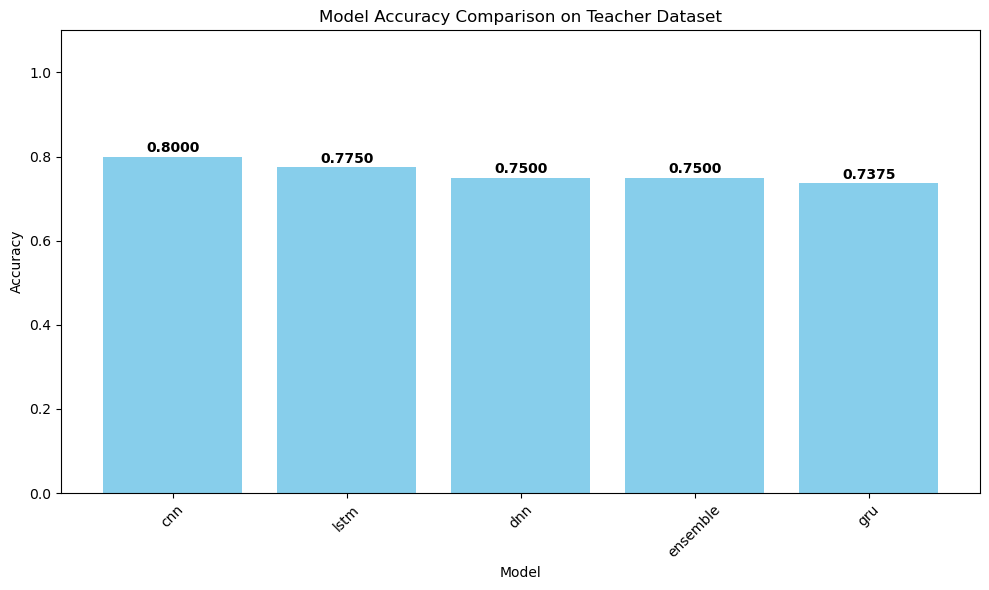


Examining incorrect predictions:

cnn made 16 incorrect predictions:
ID: D1-2
Text: The cell cycle is the process by which a cell grows, duplicates its DNA, and divides into two daught...
True label: AI, Predicted: Human (Probability: 0.0034)
--------------------------------------------------------------------------------
ID: D1-8
Text: Thalidomide is a drug that was first developed in the 1950s as a sedative and later prescribed to pr...
True label: AI, Predicted: Human (Probability: 0.1537)
--------------------------------------------------------------------------------
ID: D1-10
Text: Kepler’s laws of planetary motion are three fundamental principles that describe the motion of plane...
True label: AI, Predicted: Human (Probability: 0.0008)
--------------------------------------------------------------------------------
ID: D1-16
Text: General relativity, also known as the general theory of relativity, is a geometric theory of gravita...
True label: AI, Predicted: Human (Probabilit

In [55]:
plt.figure(figsize=(10, 6))
model_names = list(accuracies.keys())
acc_values = list(accuracies.values())

sorted_indices = np.argsort(acc_values)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_accs = [acc_values[i] for i in sorted_indices]

bars = plt.bar(sorted_names, sorted_accs, color='skyblue')

for bar, acc in zip(bars, sorted_accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{acc:.4f}',
        ha='center',
        fontweight='bold'
    )

plt.title('Model Accuracy Comparison on Teacher Dataset')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nExamining incorrect predictions:")
for model_name in predictions.keys():
    incorrect = results_df[results_df[f'{model_name}_correct'] == False]
    print(f"\n{model_name} made {len(incorrect)} incorrect predictions:")
    
    if len(incorrect) > 0:
        for _, row in incorrect.iterrows():
            true_label = 'Human' if row['numeric_label'] == 0 else 'AI'
            pred_label = 'Human' if row[f'{model_name}_pred'] == 0 else 'AI'
            print(f"ID: {row['ID']}")
            print(f"Text: {row['Text'][:100]}...")  # Show first 100 chars
            print(f"True label: {true_label}, Predicted: {pred_label} (Probability: {row[f'{model_name}_prob']:.4f})")
            print("-" * 80)


## Conclusion

In [56]:
print("\nModel Performance Summary:")
for model_name, accuracy in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {accuracy:.4f}")

if accuracies:
    best_model = max(accuracies.items(), key=lambda x: x[1])[0]
    print(f"\nBest performing model: {best_model} with accuracy {accuracies[best_model]:.4f}")
    
    if 'ensemble' in best_model:
        print("The ensemble model outperforms individual models, suggesting that combining models is effective.")
    else:
        print(f"The {best_model} model performs best on this dataset.")
else:
    print("No models were evaluated.")




Model Performance Summary:
cnn: 0.8000
lstm: 0.7750
ensemble: 0.7500
dnn: 0.7500
gru: 0.7375

Best performing model: cnn with accuracy 0.8000
The cnn model performs best on this dataset.
